<a href="https://colab.research.google.com/github/gitmystuff/DTSC5502/blob/main/Module_02-Data_and_Statistics/Statistics_with_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics

Mostly descriptive

Name

## Getting Started

* Colab - get notebook from gitmystuff DTSC5502 repository
* Save a Copy in Drive
* Remove Copy of
* Edit your name
* Clean up Colab Notebooks folder
* Submit shared link

## Inference

* Parameter vs Statistic: https://www.statisticshowto.com/statistics-basics/how-to-tell-the-difference-between-a-statistic-and-a-parameter/ (parameter describes population, statistic describes sample)
* Statistical Inference: According to Wikipedia: the process of using data analysis to infer properties of an underlying distribution of probability
* Variable: Characteristic that describes a member of the sample

Why use statistics?

* To summarize huge quantities of data
* To make better decisions
* Answer important social questions
* Recognize patterns
* Evaluate effectiveness


## Feature and Target Names
<table align="left">
    <tr>
        <th>Independent Variables (X)</th>
        <th>Dependent Variable (y)</th>
    <tr>
    <tr>
        <td>Features</td>
        <td>Target</td>
    </tr>
    <tr>
        <td>Regressors</td>
        <td>Regressand</td>
    </tr>
    <tr>
        <td>Predictors</td>
        <td>Response</td>
    </tr>
    <tr>
        <td>Observations</td>
        <td>Outcomes</td>
    </tr>
    <tr>
        <td>Explanatory</td>
        <td>Labels</td>
    </tr>
    <tr>
        <td>Input</td>
        <td>Output</td>
    </tr>
    <tr>
        <td>exog (exogenous)</td>
        <td>endog (endogenous)</td>
    </tr>
</table>

In [1]:
import pandas as pd

# grades = pd.read_csv('https://raw.githubusercontent.com/gitmystuff/Datasets/main/class-grades2.csv') # try first
# try AI Explain Error
grades = pd.read_csv('https://raw.githubusercontent.com/gitmystuff/Datasets/main/class-grades2.csv', on_bad_lines='warn')
# print shape, info, and head
print(grades.shape)
print(grades.info())
grades.head()


(103, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Prefix       103 non-null    int64  
 1   Assignment1  99 non-null     float64
 2   Tutorial     91 non-null     float64
 3   Midterm      97 non-null     float64
 4   Quiz         97 non-null     float64
 5   Final        100 non-null    float64
 6   TakeHome     96 non-null     object 
 7   Student      103 non-null    int64  
 8   Misc         2 non-null      float64
 9   Nothing      0 non-null      float64
 10  FinalGrade   103 non-null    int64  
 11  BiLabel      103 non-null    object 
dtypes: float64(7), int64(3), object(2)
memory usage: 9.8+ KB
None


Skipping line 33: expected 12 fields, saw 13



,Prefix,Assignment1,Tutorial,Midterm,Quiz,Final,TakeHome,Student,Misc,Nothing,FinalGrade,BiLabel
0,5,57.14,34.09,64.38,64.38,52.50,F,1,0.0,NaN,54,pepper
1,8,95.05,105.49,67.50,67.50,68.33,C,1,NaN,NaN,81,pepper
2,8,83.70,83.17,30.00,30.00,48.89,D,1,NaN,NaN,55,salt
3,7,81.22,96.06,49.38,49.38,80.56,C,1,NaN,NaN,71,salt
4,8,91.32,NaN,95.00,95.00,73.89,B,1,NaN,NaN,89,salt


In [2]:
# describe grades
grades.describe()

,Prefix,Assignment1,Tutorial,Midterm,Quiz,Final,Student,Misc,Nothing,FinalGrade
count,103.000000,99.000000,91.000000,97.000000,97.000000,100.00000,103.0,2.0,0.0,103.000000
mean,7.300971,85.289192,89.022527,66.450206,66.450206,68.02780,1.0,0.0,NaN,74.912621
std,0.948011,12.908363,16.353183,19.486593,19.486593,18.51751,0.0,0.0,NaN,13.442037
min,4.000000,28.140000,34.090000,28.120000,28.120000,28.06000,1.0,0.0,NaN,51.000000
25%,7.000000,80.830000,83.170000,51.250000,51.250000,52.50000,1.0,0.0,NaN,65.500000
50%,8.000000,90.100000,92.930000,67.500000,67.500000,66.25000,1.0,0.0,NaN,73.000000
75%,8.000000,95.000000,100.470000,81.250000,81.250000,83.12750,1.0,0.0,NaN,86.000000
max,8.000000,100.830000,112.580000,110.000000,110.000000,108.89000,1.0,0.0,NaN,104.000000


## Measures of Center
* Mean
* Median
* Mode

And the Normal Distribution: https://www.mathsisfun.com/data/standard-normal-distribution.html

In [3]:
# mean, median, mode
import numpy as np

print('mean:', int(np.mean(grades['Assignment1'])))
print('mean:', int(grades['Assignment1'].mean()))
print('median:', int(grades['Assignment1'].median()))
print()
print('####### mode #######')
print('mode:', grades['TakeHome'].mode())
print('mode:', grades['TakeHome'].mode()[0])

mean: 85
mean: 85
median: 90

####### mode #######
mode: 0    A
1    B
Name: TakeHome, dtype: object
mode: A


In [4]:
# grades value_counts to show mode
grades['TakeHome'].value_counts()

,count
TakeHome,
B,28
A,28
C,16
D,13
F,10
a,1


### Mean, Median, Mode Tangent

In a normal distribution, is there a mean? a median? a mode?

* Mean: $\frac{1}{N} \sum_{i=1}^{N} x_i$
* Median: $\left\{
    \begin{array}\\
        x[\frac{n+1}{2}] & \mbox{if n is odd} \\
        \frac{x[\frac{n}{2}] + x[\frac{n}{2}+1]}{2} & \mbox{if n is even}
    \end{array}
\right.
$
* Mode (ungrouped): Python collection counter
* Mode (grouped data): $l + (\frac{f_1 - f_0}{2f_1 - f_0 - f_2}) * h$

Source:

* https://stackoverflow.com/questions/10797819/finding-the-mode-of-a-list (ungrouped mode)
* https://byjus.com/maths/mode/ (example 4 for grouped mode)

### Uniform Distribution

Random value: 0.15216627003413663
50.10767
815.5599571710999
28.558010385373485


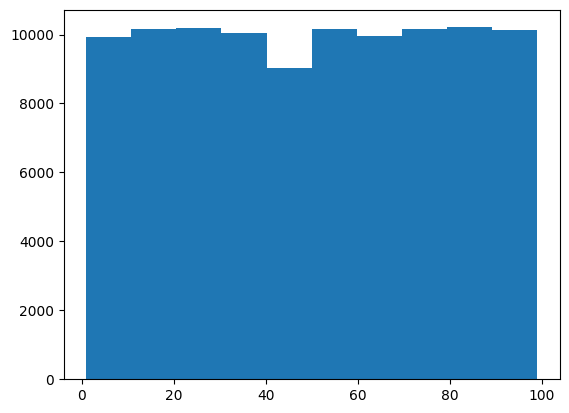

In [5]:
# uniform distribution / Python is case sensitive
import numpy as np
import matplotlib.pyplot as plt
import random

print('Random value:', random.random())

x = random.choices(range(1, 100), k=100000)
print(np.mean(x))
print(np.var(x))
print(np.std(x))
plt.hist(x)
plt.show()

### Normal Distribution

0.0008829542407510008
0.9975809747743075
0.998789755040723


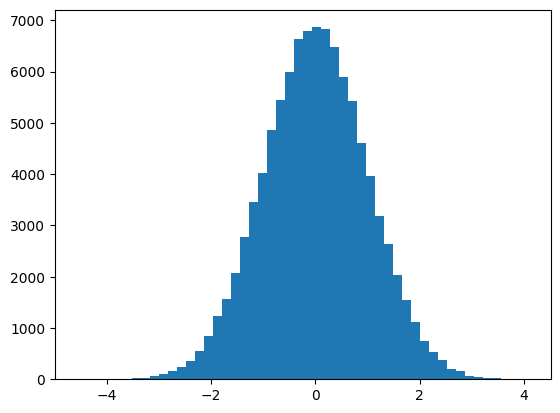

In [6]:
# normal distribution - https://realpython.com/numpy-random-normal/
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()
x = rng.normal(size=100000)
print(np.mean(x))
print(np.var(x))
print(np.std(x))
plt.hist(x, bins=50)
plt.show()

50.0234200586301
69.20619581596571
8.319026133867215


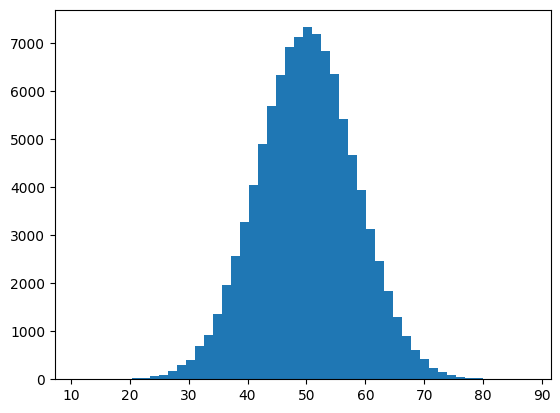

In [7]:
# another way to generate normal data using parameters
import numpy as np
import matplotlib.pyplot as plt
import random

mean, std = 50, 25/3 # check out 25/2 for std and ask what is happening?
x = [random.gauss(mean, std) for _ in range(100000)]
print(np.mean(x))
print(np.var(x))
print(np.std(x))
plt.hist(x, bins=50)
plt.show()

In [8]:
# integer data that are normally distributed
# from https://seattlecentral.edu/qelp/sets/057/057.html (housefly wing length)
import urllib.request

target_url = 'https://raw.githubusercontent.com/gitmystuff/Datasets/main/normdist.txt'
wings = []
for line in urllib.request.urlopen(target_url):
    wings.append(line.decode('utf-8'))

wing_data = [int(x.rstrip()) for x in wings] # remove line breaks
print(wing_data)
print(len(wing_data))
print(np.min(wing_data), np.max(wing_data))


[41, 45, 45, 46, 45, 42, 43, 45, 44, 45, 43, 49, 45, 48, 47, 48, 44, 52, 40, 52, 51, 51, 39, 42, 40, 48, 45, 41, 48, 49, 46, 45, 47, 48, 44, 41, 44, 49, 43, 42, 47, 49, 41, 40, 43, 46, 47, 46, 41, 45, 40, 43, 44, 45, 42, 46, 48, 46, 38, 38, 52, 43, 46, 47, 38, 50, 45, 45, 39, 50, 39, 46, 43, 41, 45, 43, 47, 49, 47, 50, 45, 50, 45, 45, 45, 39, 44, 42, 44, 45, 45, 40, 42, 42, 45, 44, 50, 47, 49, 51, 51, 46, 44, 48]
104
38 52


In [9]:
# mean - add everything up and divide by n
sum(wing_data)/len(wing_data)

45.0

In [10]:
# median - sort everthing and then find the middle value
wing_data.sort()
print(wing_data)
print('median position of 104 values:', len(wing_data)/2)
print(wing_data[int(len(wing_data)/2)])
print(wing_data[52])

[38, 38, 38, 39, 39, 39, 39, 40, 40, 40, 40, 40, 41, 41, 41, 41, 41, 41, 42, 42, 42, 42, 42, 42, 42, 43, 43, 43, 43, 43, 43, 43, 43, 44, 44, 44, 44, 44, 44, 44, 44, 44, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 46, 46, 46, 46, 46, 46, 46, 46, 46, 47, 47, 47, 47, 47, 47, 47, 47, 48, 48, 48, 48, 48, 48, 48, 49, 49, 49, 49, 49, 49, 50, 50, 50, 50, 50, 51, 51, 51, 51, 52, 52, 52]
median position of 104 values: 52.0
45
45


In [11]:
# mode - find the most frequent occurence
most_frequent = {}
for i in wing_data:
  if i in most_frequent:
    most_frequent[i] += 1
  else:
    most_frequent[i] = 1

max(most_frequent, key=most_frequent.get)

45

Variance 11.846153846153847
Standard Deviation 3.4418242032610915


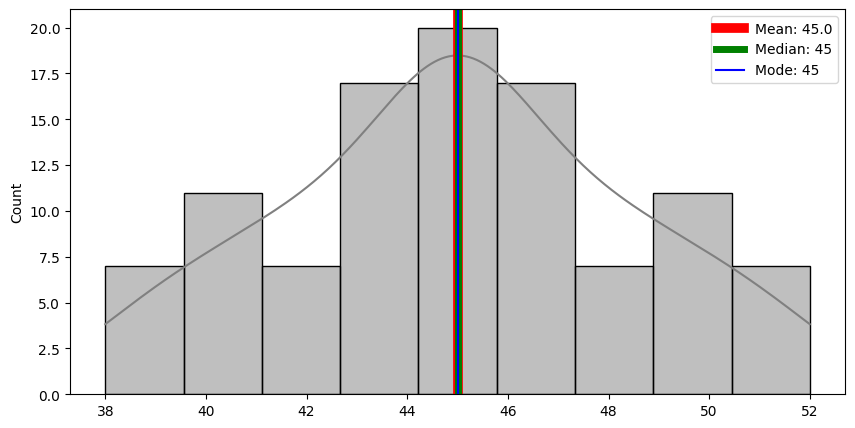

In [12]:
# plotting mean, median, mode
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

xmean = np.mean(wing_data)
xmedian = np.median(wing_data)
xmode = stats.mode(wing_data, keepdims=True)[0][0]
print('Variance', np.var(wing_data))
print('Standard Deviation', np.std(wing_data))

fig = plt.figure(figsize=(10,5))
sns.histplot(wing_data, kde=True, color='grey')
plt.axvline(x=xmean, color='red', label=f'Mean: {xmean}', linewidth=7)
plt.axvline(x=xmedian, color='green', label=f'Median: {xmode}', linewidth=5)
plt.axvline(x=xmode, color='blue', label=f'Mode: {xmode}')
plt.legend()
plt.show()

### Jelly Beans, The Wisdom of the Crowd, The Median

https://thegreatdecide.wordpress.com/category/wisdom-of-crowds/

## Measures of Spread

### Variance

The average squared deviation from the mean

Equation for mean:<br />
$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$

https://www.statology.org/sample-variance-vs-population-variance/<br />
Equation for population variance:

$\sigma^2 = \frac{1}{N}\sum(x-\mu)^2$

Equation for sample variance:<br />
$s^2 = \frac{1}{n-1} \sum (x-\bar{x})^2$

Equation for standard deviation:<br />
$\sigma = \sqrt{\frac{\sum(x-\mu)^2}{N}}$

In [13]:
# describe grades
grades.describe()

,Prefix,Assignment1,Tutorial,Midterm,Quiz,Final,Student,Misc,Nothing,FinalGrade
count,103.000000,99.000000,91.000000,97.000000,97.000000,100.00000,103.0,2.0,0.0,103.000000
mean,7.300971,85.289192,89.022527,66.450206,66.450206,68.02780,1.0,0.0,NaN,74.912621
std,0.948011,12.908363,16.353183,19.486593,19.486593,18.51751,0.0,0.0,NaN,13.442037
min,4.000000,28.140000,34.090000,28.120000,28.120000,28.06000,1.0,0.0,NaN,51.000000
25%,7.000000,80.830000,83.170000,51.250000,51.250000,52.50000,1.0,0.0,NaN,65.500000
50%,8.000000,90.100000,92.930000,67.500000,67.500000,66.25000,1.0,0.0,NaN,73.000000
75%,8.000000,95.000000,100.470000,81.250000,81.250000,83.12750,1.0,0.0,NaN,86.000000
max,8.000000,100.830000,112.580000,110.000000,110.000000,108.89000,1.0,0.0,NaN,104.000000


Variance: 0.9848033536721523


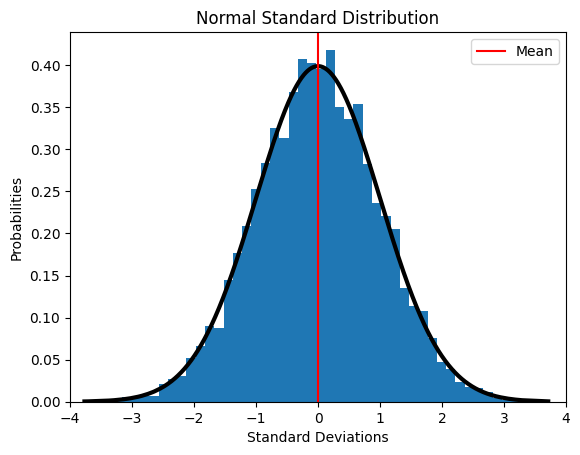

In [14]:
# standard normal distribution with numpy
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html
mu = 0
sigma = 1
x = np.random.normal(0, 1, 10000)
count, bins, ignored = plt.hist(x, density=True, bins=50)

print('Variance:', x.var(ddof=0))

# plot the distribution curve
x.sort()
plt.plot(x, 1/(np.sqrt(2 * np.pi * sigma**2)) * np.exp( -(x-mu)**2 / (2 * sigma**2) ), linewidth=3, color='k')
plt.xlabel('Standard Deviations')
plt.ylabel('Probabilities')
plt.axvline(x=mu, color='red', label='Mean')
plt.xlim(-4, 4)
plt.title('Normal Standard Distribution')
plt.legend()
plt.show()

In [15]:
# describe grades
grades.describe()

,Prefix,Assignment1,Tutorial,Midterm,Quiz,Final,Student,Misc,Nothing,FinalGrade
count,103.000000,99.000000,91.000000,97.000000,97.000000,100.00000,103.0,2.0,0.0,103.000000
mean,7.300971,85.289192,89.022527,66.450206,66.450206,68.02780,1.0,0.0,NaN,74.912621
std,0.948011,12.908363,16.353183,19.486593,19.486593,18.51751,0.0,0.0,NaN,13.442037
min,4.000000,28.140000,34.090000,28.120000,28.120000,28.06000,1.0,0.0,NaN,51.000000
25%,7.000000,80.830000,83.170000,51.250000,51.250000,52.50000,1.0,0.0,NaN,65.500000
50%,8.000000,90.100000,92.930000,67.500000,67.500000,66.25000,1.0,0.0,NaN,73.000000
75%,8.000000,95.000000,100.470000,81.250000,81.250000,83.12750,1.0,0.0,NaN,86.000000
max,8.000000,100.830000,112.580000,110.000000,110.000000,108.89000,1.0,0.0,NaN,104.000000


### Quartiles

https://en.wikipedia.org/wiki/Interquartile_range

Interquartile range<br />
Whiskers<br />

Outliers<br />
Fence<br />
* https://www.statisticshowto.com/upper-and-lower-fences/
* https://www.researchgate.net/figure/The-main-components-of-a-boxplot-median-quartiles-whiskers-fences-and-outliers_fig6_303779929

Boxplots<br />
Violin plots

### Whiskers and Fences

In a box and whisker plot, whiskers are lines that extend from the lower and upper hinges to the smallest and largest data values within the inner fence. The fences at the ends of the whiskers indicate cutoff values beyond which any point would be considered an outlier. The whiskers don't extend to the fences unless there are actual data points at those places. (Bard, 2023)

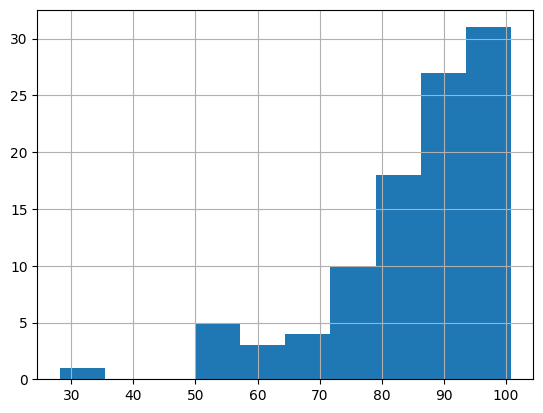

In [16]:
# Assignment histogram
grades['Assignment1'].hist();

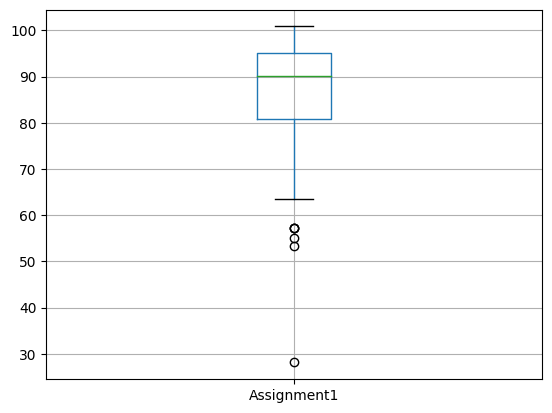

In [17]:
# Assignment boxplot
grades.boxplot(column=['Assignment1']);

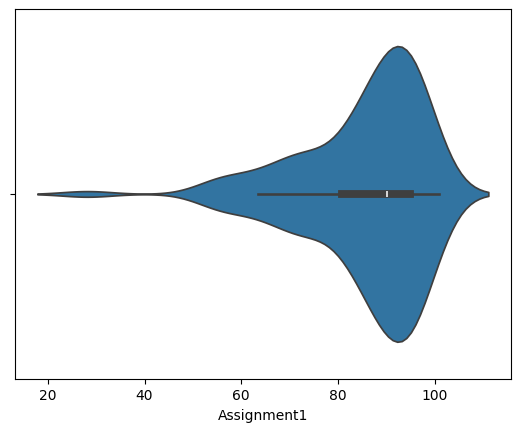

In [18]:
# Assignment violinplot
import seaborn as sns

sns.violinplot(x=grades['Assignment1']);

## Measures of Shape

https://www.analyticsvidhya.com/blog/2021/05/shape-of-data-skewness-and-kurtosis/

**Skewness**
* Skewed right
* Skewed left

**Kurtosis**
* Mesokurtic
* Leptokurtic
* Platykurtic

### Outliers Tangent

When we have a data set with outliers that skew the data, the median will be a better measure of central tendency than the mean, and the interquartile range will be a better measure of spread than standard deviation.

https://www.kristakingmath.com/blog/symmetric-and-skewed-distributions#:~:text=When%20we%20have%20a%20data,of%20spread%20than%20standard%20deviation.

mean before outliers: -0.10384651739409385
var before outliers: 0.8165221946938582


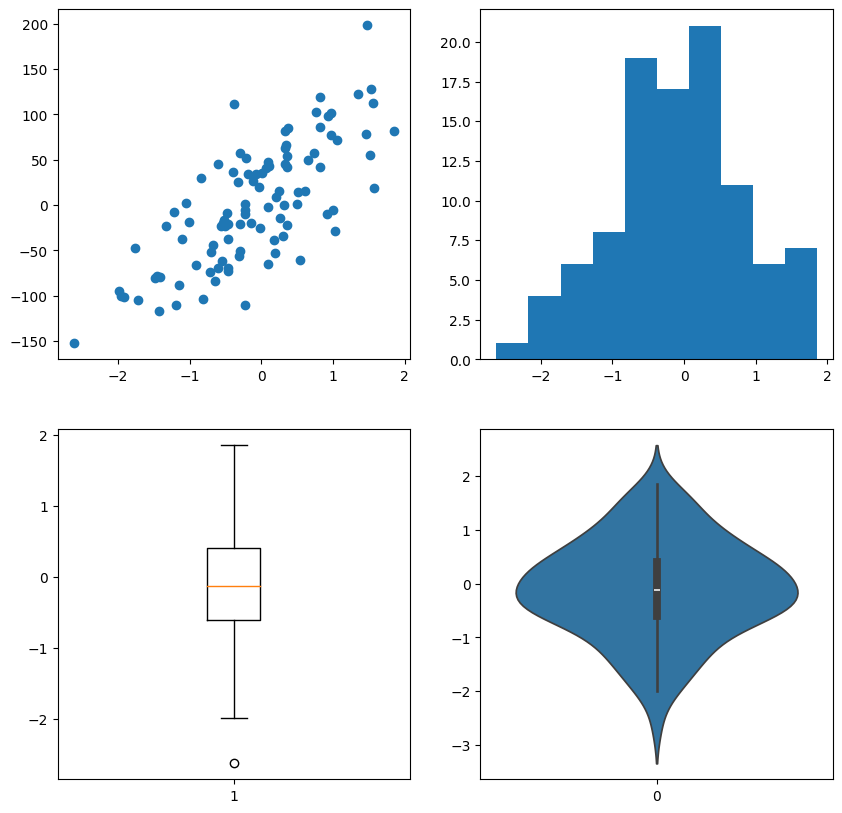

In [19]:
# visualize outliers before and after
from random import random
from random import randint
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=1, noise=50, random_state=42)
print('mean before outliers:', np.mean(X))
print('var before outliers:', np.var(X))
fig, ([ax1, ax2], [ax3, ax4]) = plt.subplots(2, 2, figsize=(10, 10))
ax1.scatter(X, y)
ax2.hist(X)
ax3.boxplot(X)
sns.violinplot(ax=ax4, data=X);

mean after outliers: 0.12198751325958636
var after outliers: 3.1631071532925317


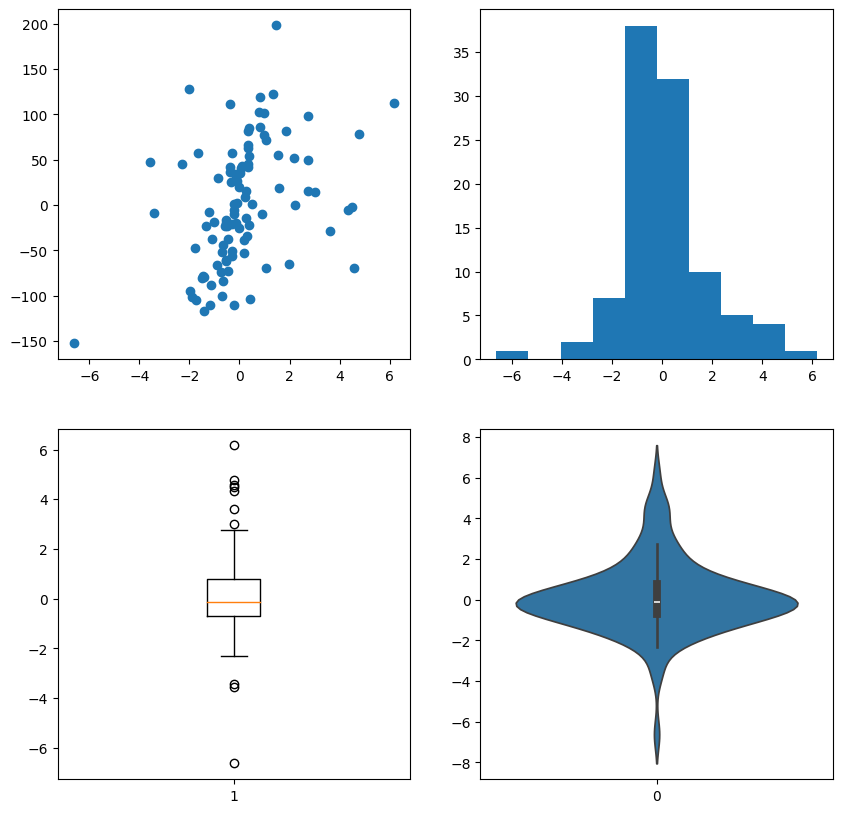

In [20]:
# create outliers
for i in range(30):
    factor = randint(-3, 3)
    if random() > 0.5:
        X[i] += factor * X.std()
    else:
        X[i] -= factor * X.std()

fig, ([ax1, ax2], [ax3, ax4]) = plt.subplots(2, 2, figsize=(10, 10))
ax1.scatter(X, y)
ax2.hist(X)
ax3.boxplot(X)
sns.violinplot(ax=ax4, data=X)
print('mean after outliers:', np.mean(X))
print('var after outliers:', np.var(X))

### Skewed data

https://www.itl.nist.gov/div898/handbook/eda/section3/eda33e6.htm

Occur due to upper or lower bounds on the data<br />
https://www.mathsisfun.com/definitions/upper-bound.html<br />
Mean, Median, and Mode should be mentioned because there is no center in the usual sense<br />

**Right Skewed**
* Tail is on the right side
* Mode Median Mean
* Data have a lower bound

**Left Skewed**
* Tail is on the left
* Mean Median Mode
* Data have an upper bound

right skew data mean: 7.93, median: 6.74
left skew data mean: -7.95, median: -6.74


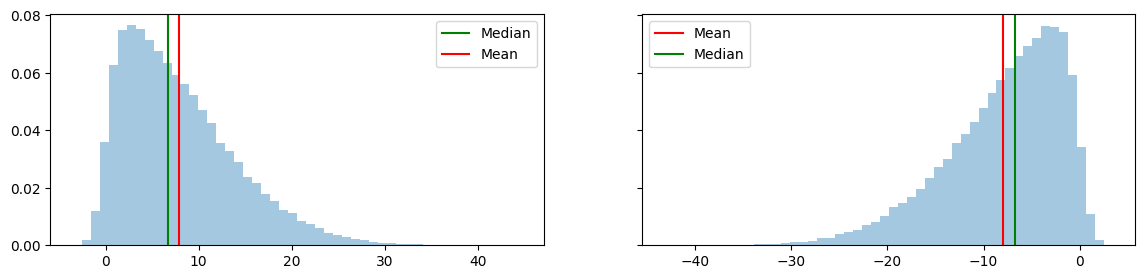

In [21]:
import numpy as np
from scipy.stats import skewnorm
from scipy import stats
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(14, 3))
skew = 10
n = 100000

r = skewnorm.rvs(skew, loc=0, scale=10, size=n)
ax[0].hist(r, bins=50, density=True, alpha=0.4)
ax[0].axvline(x=np.median(r), color='green', label='Median')
ax[0].axvline(x=np.mean(r).round(2), color='red', label='Mean')
ax[0].legend()
print(f'right skew data mean: {np.mean(r).round(2)}, median: {np.median(r).round(2)}')

l = skewnorm.rvs(-skew, loc=0, scale=10, size=n)
ax[1].hist(l, bins=50, density=True, alpha=0.4);
ax[1].axvline(x=np.mean(l).round(2), color='red', label='Mean')
ax[1].axvline(x=np.median(l), color='green', label='Median')
ax[1].legend()
print(f'left skew data mean: {np.mean(l).round(2)}, median: {np.median(l).round(2)}')

### Kurtosis

https://www.investopedia.com/terms/p/platykurtic.asp

* Mesokurtic: Extreme events are rare, resembles normal distribution
* Platykurtic: Excess kurtosis is negative (< 3) and has thinner tails. Fewer extreme events. In finance, risk-averse investors might perfer platykurtic distributions
* Leptokurtic: Excess kurtosis is greater than 3 and has fatter tails. Caused by extreme events or outliers.

According to Investopedia (2022):

> Risk-seeking investors can focus on investments whose returns follow a leptokurtic distribution, to maximize the chances of rare events—both positive and negative (para 3).

Leptokurtic Definition. (2022, February 1). In *Investopedia*. https://www.investopedia.com/terms/l/leptokurtic.asp.

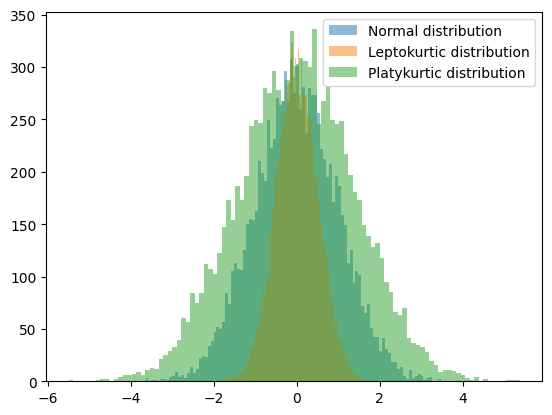

In [22]:
import numpy as np
from scipy.stats import norm

# generate a normal distribution
normal_dist = norm(0, 1)
normal_samples = normal_dist.rvs(10000)

# generate a leptokurtic distribution
leptokurtic_dist = norm(loc=0, scale=0.5)
leptokurtic_samples = leptokurtic_dist.rvs(10000)

# generate a platykurtic distribution
platykurtic_samples = normal_samples + np.random.randn(10000)

# plot the distributions
import matplotlib.pyplot as plt
plt.hist(normal_samples, bins=100, alpha=0.5, label='Normal distribution')
plt.hist(leptokurtic_samples, bins=100, alpha=0.5, label='Leptokurtic distribution')
plt.hist(platykurtic_samples, bins=100, alpha=0.5, label='Platykurtic distribution')
plt.legend()
plt.show()

https://www.kaggle.com/getting-started/170781

Skewness essentially measures the symmetry of the distribution, while kurtosis determines the heaviness of the distribution tails.

The topic of Kurtosis has been controversial for decades now, the basis of kurtosis all these years has been linked with the peakedness but the ultimate verdict is that outliers (fatter tails) govern the kurtosis effect far more than the values near the mean (peak).

https://towardsdatascience.com/skewness-kurtosis-simplified-1338e094fc85

### Moments

According to Wikipedia (2022):

>  If the function is a probability distribution, then the first moment is the expected value, the second central moment is the variance, the third standardized moment is the skewness, and the fourth standardized moment is the kurtosis (para 1).

Moment (mathematics). (2022, January 31). In *Wikipedia*. https://en.wikipedia.org/wiki/Moment_(mathematics).

Mean:<br />
$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$v

Variance:<br />
$s^2 = \frac{\sum (x - \bar{x})^2}{n-1}$

Skewness:<br />
$\frac{\frac{1}{n}\sum(x - \mu)^3}{\sigma^3}$

Kurtosis:<br />
$\frac{\frac{1}{n}\sum(x - \mu)^4}{\sigma^4}$

More reading: https://gregorygundersen.com/blog/2020/04/11/moments/

## Correlation

According to Wikipedia (2022):

>  In statistics, correlation or dependence is any statistical relationship, whether causal or not, between two random variables or bivariate data. In the broadest sense correlation is any statistical association, though it actually refers to the degree to which a pair of variables are linearly related. Familiar examples of dependent phenomena include the correlation between the height of parents and their offspring, and the correlation between the price of a good and the quantity the consumers are willing to purchase... Correlations - 2 are useful because they can indicate a predictive relationship that can be exploited in practice (paras. 1 - 2).

Correlation. (2022, February 1). In *Wikipedia*. https://en.wikipedia.org/wiki/Correlation.

Correlation does not cause causation. Warm days on the beach, ice cream, and shark bites.

Covariance:<br />
$cov(x, y) = \frac{1}{N} \sum_{i=1}^{N}(x_i - \bar{x}) (y_i - \bar{y})$

* Shows how variables change together
* A measure of correlation
* Measures direction

Pearson’s r (correlation coefficient):<br />
$\rho_{x,y} = \frac{cov(x,y)}{\sigma_x\sigma_y} = \frac{\frac{1}{N}\sum(x-\bar{x})(y-\bar{y})}{\sqrt\frac{\sum(x-\bar{x})^2}{N}\sqrt\frac{\sum(y-\bar{y})^2}{N}}  = \frac{\sum(x-\bar{x})(y-\bar{y})}{\sqrt{\sum(x-\bar{x})^2}\sqrt{\sum(y-\bar{y})^2}}$

* Shows linear relationship between two continuous variables
* How one variable changes as another variable changes
* Measures both strength and direction

Resources:

* https://statistics.laerd.com/statistical-guides/pearson-correlation-coefficient-statistical-guide.php
* https://www.mygreatlearning.com/blog/covariance-vs-correlation/


### Train Test Split

In [23]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(grades.drop('FinalGrade', axis=1), grades['FinalGrade'], test_size=.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
X_train.head()

(82, 11)
(21, 11)


,Prefix,Assignment1,Tutorial,Midterm,Quiz,Final,TakeHome,Student,Misc,Nothing,BiLabel
53,8,92.46,95.75,61.88,61.88,48.89,B,1,NaN,NaN,salt
22,4,92.01,102.52,38.75,38.75,49.17,B,1,NaN,NaN,salt
68,7,91.28,108.71,NaN,NaN,88.89,A,1,NaN,NaN,pepper
44,6,28.14,58.51,72.50,72.50,68.33,D,1,NaN,NaN,pepper
98,8,96.73,103.71,45.00,45.00,61.94,A,1,NaN,NaN,salt


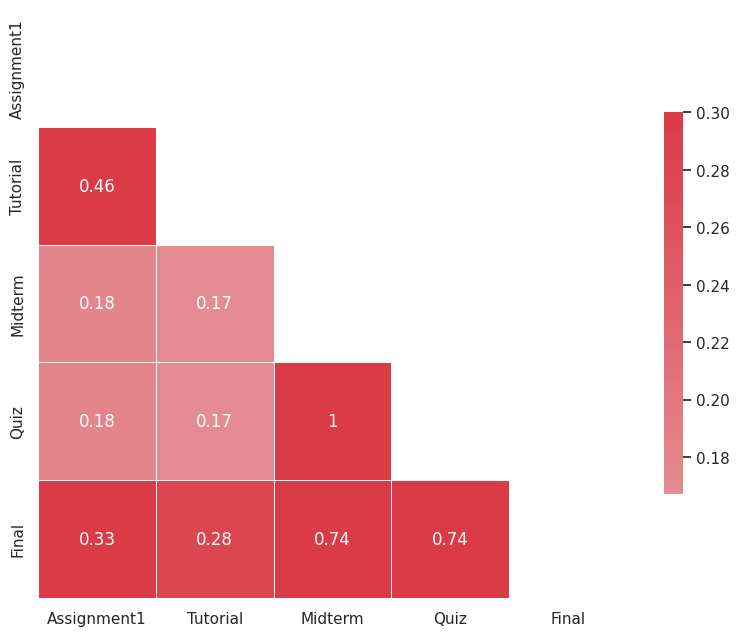

In [24]:
# show correlation between the features especially between (Quiz and Midterm) and (Midterm, Quiz and Final)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# correlation matrix
sns.set(style="white")

# compute the correlation matrix
corr = X_train._get_numeric_data().drop(['Prefix', 'Student', 'Misc', 'Nothing'], axis=1).corr()

# generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# set up the matplotlib figure
# f, ax = plt.subplots()
f = plt.figure(figsize=(8, 8))

# generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True);

plt.tight_layout()

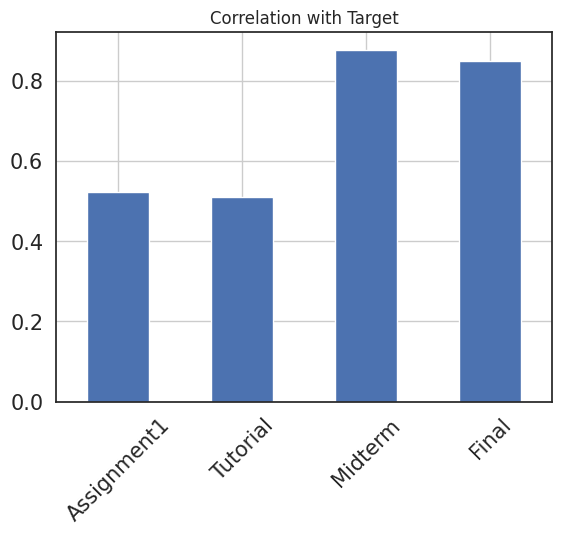

In [25]:
# showing correlation of multiple features with one target
X_train.drop(['Prefix', 'Student', 'Misc', 'Nothing', 'Quiz'], axis=1).corrwith(y_train, numeric_only=True).plot.bar(
        title = "Correlation with Target", fontsize = 15,
        rot = 45, grid = True);

### Multicollinearity
The need to reduce multicollinearity depends on its severity and your primary goal for your regression model. Keep the following three points in mind:
* The severity of the problems increases with the degree of the multicollinearity. Therefore, if you have only moderate multicollinearity, you may not need to resolve it.
* Multicollinearity affects only the specific independent variables that are correlated. Therefore, if multicollinearity is not present for the independent variables that you are particularly interested in, you may not need to resolve it. Suppose your model contains the experimental variables of interest and some control variables. If high multicollinearity exists for the control variables but not the experimental variables, then you can interpret the experimental variables without problems.
* Multicollinearity affects the coefficients and p-values, but it does not influence the predictions, precision of the predictions, and the goodness-of-fit statistics. If your primary goal is to make predictions, and you don’t need to understand the role of each independent variable, you don’t need to reduce severe multicollinearity.
https://statisticsbyjim.com/regression/multicollinearity-in-regression-analysis/

### Spurious Correlations

* https://www.tylervigen.com/spurious-correlations

# Law of Large Numbers and Central Limit Theory

* See Notebooks
* Jakob Bernoulli
* Abraham De Moivre